In [1]:
import torch
print("CUDA是否可用:", torch.cuda.is_available())
print("GPU型号:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "无GPU，请检查运行时设置")
print("PyTorch版本:", torch.__version__)

CUDA是否可用: True
GPU型号: Tesla T4
PyTorch版本: 2.10.0+cu128


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

# 与改进版完全一致的项目根目录，确保数据集复用
PROJECT_ROOT = "/content/drive/MyDrive/Medical_project/rsna-yolov8"
DATASET_DIR = os.path.join(PROJECT_ROOT, "dataset")
YOLO_DATA_DIR = os.path.join(DATASET_DIR, "rsna_yolo")

# 批量创建目录，已存在则不修改
for dir_path in [PROJECT_ROOT, DATASET_DIR, YOLO_DATA_DIR]:
    os.makedirs(dir_path, exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATA_DIR, "images/train"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATA_DIR, "images/val"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATA_DIR, "labels/train"), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATA_DIR, "labels/val"), exist_ok=True)

print("项目目录初始化完成，根目录路径:", PROJECT_ROOT)

项目目录初始化完成，根目录路径: /content/drive/MyDrive/Medical project/rsna-yolov8


In [4]:
# 升级pip
!pip install --upgrade pip

# 安装基线版所需核心依赖（无额外自定义包）
!pip install ultralytics pydicom pandas opencv-python numpy

# 验证安装成功
!yolo version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 90.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 113.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ultralytics]
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.41


In [5]:
from google.colab import files
import os

print("请上传你下载的kaggle.json文件")
uploaded = files.upload()

# 配置Kaggle API权限
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 验证配置成功
!kaggle competitions list

请上传你下载的kaggle.json文件


Saving kaggle.json to kaggle.json
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/

In [13]:
import os
PROJECT_ROOT = "/content/drive/MyDrive/Medical_project/rsna-yolov8"
DATASET_DIR = os.path.join(PROJECT_ROOT, "dataset")
RAW_DATA_DIR = os.path.join(DATASET_DIR, "rsna-pneumonia-detection-challenge")

# 下载数据集
%cd $DATASET_DIR
!kaggle competitions download -c rsna-pneumonia-detection-challenge

# 解压数据集
!unzip -q rsna-pneumonia-detection-challenge.zip -d $RAW_DATA_DIR

# 验证解压完成
print("数据集解压完成，文件列表：")
!ls $RAW_DATA_DIR

/content/drive/MyDrive/Medical_project/rsna-yolov8/dataset
Resuming from 482344960 bytes (3449942570 bytes left)...
100% 3.66G/3.66G [03:47<00:00, 15.2MB/s]

数据集解压完成，文件列表：
'GCP Credits Request Link - RSNA.txt'   stage_2_test_images
 stage_2_detailed_class_info.csv        stage_2_train_images
 stage_2_sample_submission.csv	        stage_2_train_labels.csv


In [14]:
%%writefile /content/drive/MyDrive/Medical_project/rsna-yolov8/rsna_to_yolo.py
import os
import pydicom
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm

# 路径配置（与改进版完全一致）
RAW_DATA_DIR = "/content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna-pneumonia-detection-challenge"
YOLO_DATA_DIR = "/content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo"
IMAGE_SIZE = 512  # 与训练参数完全对齐

# 读取标签文件
labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, "stage_2_train_labels.csv"))
image_ids = labels_df["patientId"].unique()

print(f"总共有 {len(image_ids)} 张图像，开始转换...")

# 批量转换
for patient_id in tqdm(image_ids):
    # 读取DICOM图像
    dicom_path = os.path.join(RAW_DATA_DIR, "stage_2_train_images", f"{patient_id}.dcm")
    dicom = pydicom.dcmread(dicom_path)
    image = dicom.pixel_array

    # 缩放至512x512
    orig_h, orig_w = image.shape
    scale_w = IMAGE_SIZE / orig_w
    scale_h = IMAGE_SIZE / orig_h
    image_resized = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # 保存图像
    img_save_path = os.path.join(YOLO_DATA_DIR, "images/train", f"{patient_id}.jpg")
    cv2.imwrite(img_save_path, image_resized)

    # 生成YOLO格式标签
    label_save_path = os.path.join(YOLO_DATA_DIR, "labels/train", f"{patient_id}.txt")
    box_df = labels_df[labels_df["patientId"] == patient_id]

    with open(label_save_path, "w") as f:
        for _, row in box_df.iterrows():
            if row["Target"] == 0:
                continue
            # 坐标转换与归一化
            x = row["x"] * scale_w
            y = row["y"] * scale_h
            w = row["width"] * scale_w
            h = row["height"] * scale_h

            x_center = (x + w / 2) / IMAGE_SIZE
            y_center = (y + h / 2) / IMAGE_SIZE
            width_norm = w / IMAGE_SIZE
            height_norm = h / IMAGE_SIZE

            # 写入标签，类别ID为0，与改进版完全一致
            f.write(f"0 {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}\n")

print("✅ 数据转换完成！")

Overwriting /content/drive/MyDrive/Medical_project/rsna-yolov8/rsna_to_yolo.py


In [15]:
%cd /content/drive/MyDrive/Medical_project/rsna-yolov8
!python rsna_to_yolo.py

/content/drive/MyDrive/Medical_project/rsna-yolov8
总共有 26684 张图像，开始转换...
100% 26684/26684 [20:16<00:00, 21.94it/s]
✅ 数据转换完成！


In [1]:
import os
import random
import shutil
from tqdm import tqdm

YOLO_DATA_DIR = "/content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo"
train_img_dir = os.path.join(YOLO_DATA_DIR, "images/train")
val_img_dir = os.path.join(YOLO_DATA_DIR, "images/val")
train_label_dir = os.path.join(YOLO_DATA_DIR, "labels/train")
val_label_dir = os.path.join(YOLO_DATA_DIR, "labels/val")

# 固定随机种子，与改进版划分结果完全一致
random.seed(42)
all_images = [f for f in os.listdir(train_img_dir) if f.endswith(".jpg")]
random.shuffle(all_images)

# 8:2划分，与改进版一致
val_ratio = 0.2
val_num = int(len(all_images) * val_ratio)
val_images = all_images[:val_num]

print(f"总图像数：{len(all_images)}，训练集：{len(all_images)-val_num}，验证集：{val_num}")

# 移动验证集文件
for img_name in tqdm(val_images):
    # 移动图像
    src_img = os.path.join(train_img_dir, img_name)
    dst_img = os.path.join(val_img_dir, img_name)
    shutil.move(src_img, dst_img)

    # 移动标签
    label_name = img_name.replace(".jpg", ".txt")
    src_label = os.path.join(train_label_dir, label_name)
    dst_label = os.path.join(val_label_dir, label_name)
    if os.path.exists(src_label):
        shutil.move(src_label, dst_label)

print("✅ 训练集/验证集划分完成！")

总图像数：4081，训练集：3265，验证集：816


100%|██████████| 816/816 [00:21<00:00, 37.61it/s] 

✅ 训练集/验证集划分完成！


In [7]:
%%writefile /content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo/data.yaml
path: /content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo
train: images/train
val: images/val
nc: 1
names:
  0: nodule

Writing /content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo/data.yaml


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.6 MB/s eta 0:00:00


In [8]:
%%writefile /content/drive/MyDrive/Medical_project/rsna-yolov8/train_yolov8_original.py
from ultralytics import YOLO

# 训练主逻辑
if __name__ == "__main__":
    # 加载官方原生YOLOv8预训练模型，与改进版模型版本保持一致（n/s/m/l/x可选）
    model = YOLO("yolov8n.pt")

    # 训练参数：与改进版完全一致，仅修改name区分实验
    model.train(
        data='/content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo/data.yaml',
        epochs=80,      # 必须与改进版完全一致
        imgsz=512,      # 必须与改进版完全一致
        batch=8,        # 必须与改进版完全一致
        device='0',
        workers=4,      # Colab为Linux环境，无需设0，提升加载速度
        patience=20,    # 早停机制，与改进版一致
        project='/content/drive/MyDrive/Medical_project/rsna-yolov8/runs_rsna',
        name='original_baseline', # 实验目录名，与改进版区分
        exist_ok=True,
        verbose=True,
        amp=True,       # 混合精度训练，与改进版环境一致
        box=7.5,        # 官方默认损失权重，不做任何修改
        cls=0.5,        # 官方默认分类损失权重
        dfl=1.5         # 官方默认DFL损失权重
    )

    # 训练完成后自动执行评估
    metrics = model.val()
    print("="*50)
    print("✅ 原版基线模型训练完成，最终评估指标：")
    print(f"mAP50: {metrics.box.map50:.3f}")
    print(f"mAP50-95: {metrics.box.map:.3f}")
    print(f"Recall: {metrics.box.recall.mean():.3f}")
    print("="*50)
    print("请将上述指标填入README的基准评估结果中，用于与改进版对比分析")

Overwriting /content/drive/MyDrive/Medical_project/rsna-yolov8/train_yolov8_original.py


In [9]:
%cd /content/drive/MyDrive/Medical_project/rsna-yolov8
!python train_yolov8_original.py

/content/drive/MyDrive/Medical_project/rsna-yolov8
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Medical_project/rsna-yolov8/dataset/rsna_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=origina

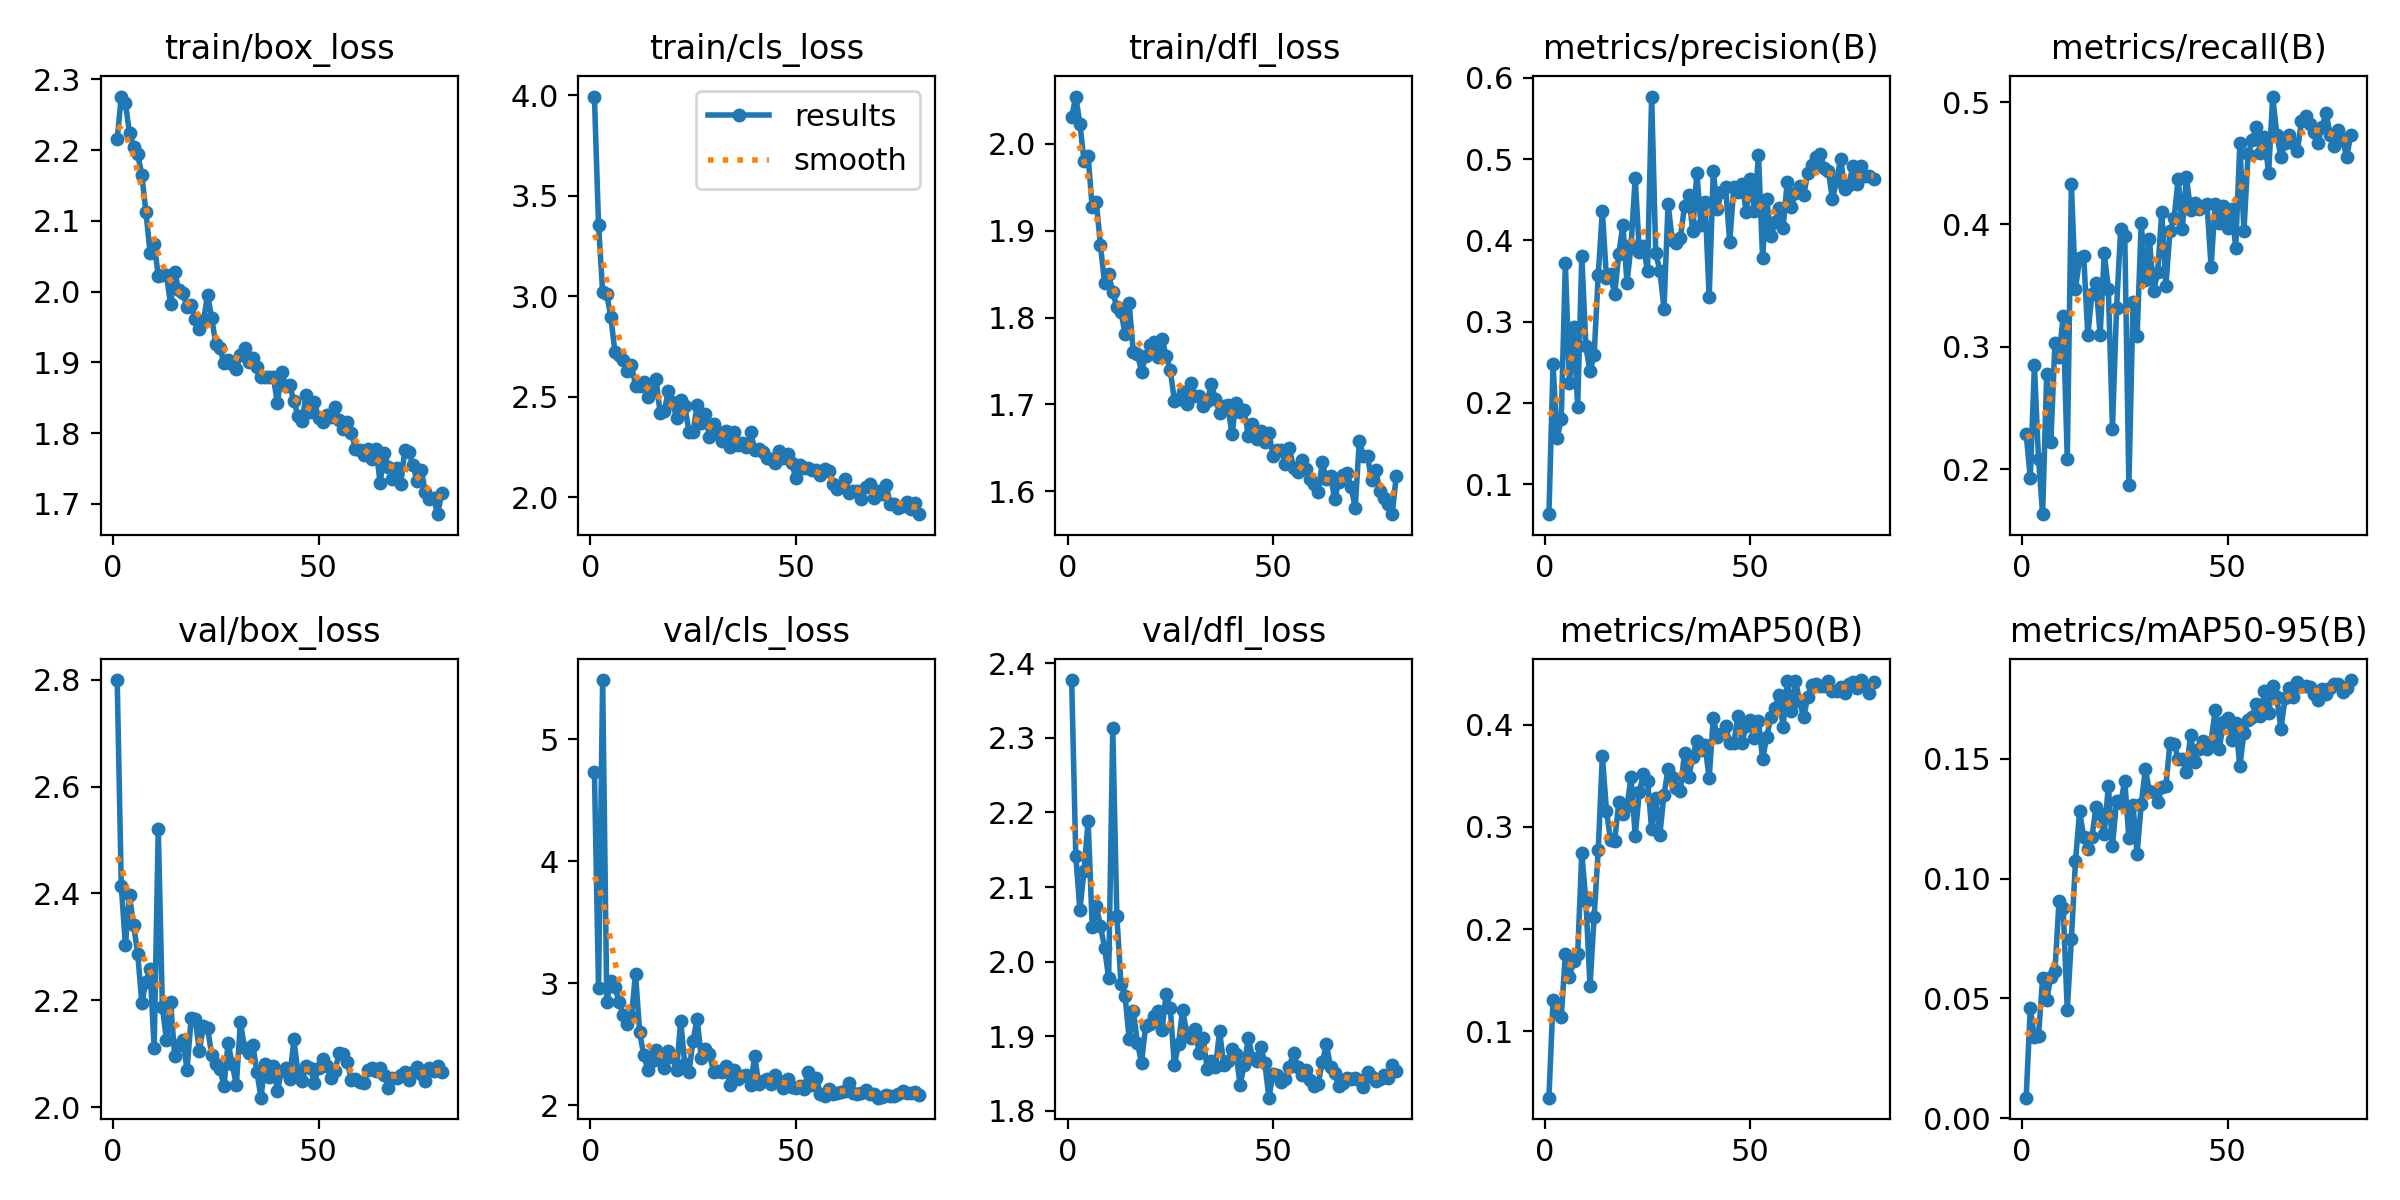

In [10]:
from IPython.display import Image
Image('/content/drive/MyDrive/Medical_project/rsna-yolov8/runs_rsna/original_baseline/results.png', width=800)